<a href="https://colab.research.google.com/github/moniml/mlopstraining/blob/main/One_hot_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/carprices.csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [ ]:
dummies = pd.get_dummies(df['Car Model']).astype(int)
dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [ ]:
merged=pd.concat([df,dummies],axis='columns')
merged

,Car Model,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,0,1,0
1,BMW X5,35000,34000,3,0,1,0
2,BMW X5,57000,26100,5,0,1,0
3,BMW X5,22500,40000,2,0,1,0
4,BMW X5,46000,31500,4,0,1,0
5,Audi A5,59000,29400,5,1,0,0
6,Audi A5,52000,32000,5,1,0,0
7,Audi A5,72000,19300,6,1,0,0
8,Audi A5,91000,12000,8,1,0,0
9,Mercedez Benz C class,67000,22000,6,0,0,1


In [ ]:
final=merged.drop(["Car Model"],axis='columns')
final

,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,69000,18000,6,0,1,0
1,35000,34000,3,0,1,0
2,57000,26100,5,0,1,0
3,22500,40000,2,0,1,0
4,46000,31500,4,0,1,0
5,59000,29400,5,1,0,0
6,52000,32000,5,1,0,0
7,72000,19300,6,1,0,0
8,91000,12000,8,1,0,0
9,67000,22000,6,0,0,1


In [ ]:
x=final.drop('Sell Price($)',axis='columns')
x

,Mileage,Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,69000,6,0,1,0
1,35000,3,0,1,0
2,57000,5,0,1,0
3,22500,2,0,1,0
4,46000,4,0,1,0
5,59000,5,1,0,0
6,52000,5,1,0,0
7,72000,6,1,0,0
8,91000,8,1,0,0
9,67000,6,0,0,1


In [ ]:
y=final['Sell Price($)']
y

,Sell Price($)
0,18000
1,34000
2,26100
3,40000
4,31500
5,29400
6,32000
7,19300
8,12000
9,22000


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [ ]:
model.fit(x,y)

LinearRegression()

In [ ]:
model.predict(x)

array([18705.2723644 , 35286.78445645, 24479.19112468, 41245.76426391,
       29882.98779056, 28023.6135243 , 30614.46818502, 21879.57266964,
       12182.34562104, 26183.72387884, 18929.31674102, 20409.80511857,
       30477.15426156])

In [ ]:
model.score(x,y)

0.9417050937281083

predict of mercendez benz that is 4 yr old with mileage 45000

In [ ]:
import pandas as pd
new_car = pd.DataFrame(
    [[45000,4,0,0,1]],
    columns=['Mileage','Age(yrs)','Audi A5','BMW X5','Mercedez Benz C class']
)
prediction = model.predict(new_car)
print(prediction)

[36991.31721061]


predict of bmw x5 that is 4 yr old with mileage 45000

In [ ]:
import pandas as pd
new_car = pd.DataFrame(
    [[86000, 7, 0, 1, 0]],
    columns=['Mileage','Age(yrs)','Audi A5','BMW X5','Mercedez Benz C class']
)
predicted_price = model.predict(new_car)
print(predicted_price)

[11080.74313219]


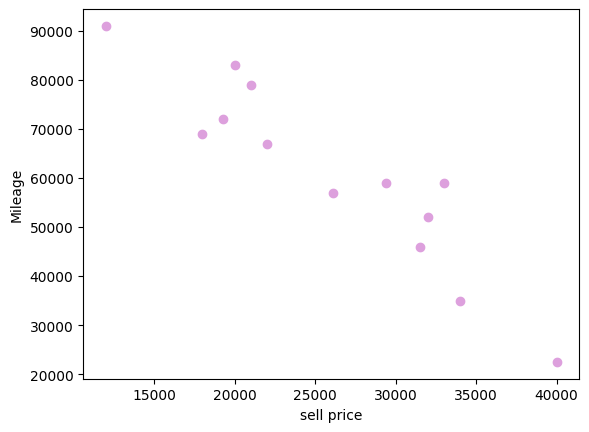

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/carprices.csv")
plt.scatter(df['Sell Price($)'],df['Mileage'],color="plum")
plt.xlabel("sell price")
plt.ylabel("Mileage")
plt.show()

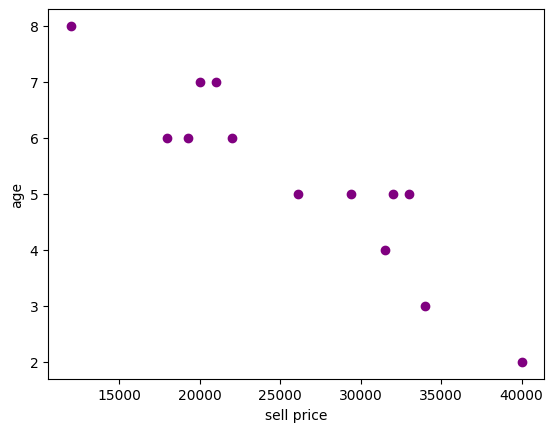

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/carprices.csv")
plt.scatter(df['Sell Price($)'],df['Age(yrs)'],color="purple")
plt.xlabel("sell price")
plt.ylabel("age")
plt.show()